# Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [21]:
# udf_raw = pd.read_csv("uniwersal_results.csv", sep=';', header=None, names=["algo", "threads", "t", "t1", "t2", "t3", "t4"])
# udf_raw = pd.read_csv("results.csv", sep=';', header=None)
udf_raw = pd.read_csv("results_uni_3.csv", sep=';', header=None, names=["algo", "threads", "t", "t1", "t2", "t3", "t4"])
udf_raw.head()


,algo,threads,t,t1,t2,t3,t4
0,sort_1,15,0.342947,0.007455,0.083681,0.120833,0.003793
1,sort_1,15,0.342695,0.007181,0.083551,0.119867,0.003610
2,sort_1,15,0.342566,0.007435,0.083729,0.120412,0.003500
3,sort_1,15,0.342761,0.007238,0.083571,0.120389,0.003584
4,sort_1,15,0.340439,0.007134,0.083626,0.120028,0.003596


In [35]:
sum([el for i, el in enumerate(udf_raw.iloc[0])])

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [28]:
udf_raw.groupby(['algo', 'threads']).mean().reset_index()

,algo,threads,t,t1,t2,t3,t4
0,sort_1,1,2.894957,0.099687,0.321399,2.449132,0.015261
1,sort_1,2,2.001193,0.068795,0.353888,1.536923,0.007433
2,sort_1,3,1.557436,0.047114,0.267740,1.095873,0.005266
3,sort_1,4,0.831276,0.025563,0.178660,0.519300,0.004308
4,sort_1,5,0.690771,0.020550,0.159086,0.408602,0.003802
5,sort_1,6,0.700393,0.026068,0.176191,0.347828,0.003268
6,sort_1,7,0.530898,0.014865,0.124340,0.282972,0.003121
7,sort_1,8,0.484022,0.012961,0.115505,0.242709,0.002255
8,sort_1,9,0.447900,0.011628,0.107610,0.214108,0.002661
9,sort_1,10,0.477726,0.024469,0.114240,0.189349,0.003712


In [14]:
bdf_raw = pd.read_csv("bucket_variable_results.csv", sep=';', header=None, names=["algo", "buckets", "t", "t1", "t2", "t3", "t4"])
bdf_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: 'bucket_variable_results.csv'

In [22]:
bdf_raw = pd.read_csv("results_oriented.csv", sep=';', header=None, names=["algo", "threads", "buckets","t", "t1", "t2", "t3", "t4"])
bdf_raw.head()

,algo,threads,buckets,t,t1,t2,t3,t4
0,sort_1,10,70000,0.493081,0.010531,0.127912,0.089174,0.004275
1,sort_1,10,70000,0.479718,0.010757,0.129723,0.089635,0.005030
2,sort_1,10,70000,0.487103,0.010944,0.130628,0.089322,0.005725
3,sort_1,10,70000,0.480353,0.010649,0.130854,0.089723,0.005556
4,sort_1,10,70000,0.490934,0.010386,0.129880,0.089316,0.005503


In [17]:
odf_raw = pd.read_csv("results_uni.csv", sep=';', header=None, names=["algo", "threads", "buckets", "t", "t1", "t2", "t3", "t4"])
odf_raw.head()
# odf_raw

,algo,threads,buckets,t,t1,t2,t3,t4
0,sort_1,15,0.342947,0.007455,0.083681,0.120833,0.003793,NaN
1,sort_1,15,0.342695,0.007181,0.083551,0.119867,0.003610,NaN
2,sort_1,15,0.342566,0.007435,0.083729,0.120412,0.003500,NaN
3,sort_1,15,0.342761,0.007238,0.083571,0.120389,0.003584,NaN
4,sort_1,15,0.340439,0.007134,0.083626,0.120028,0.003596,NaN


In [23]:
udf = udf_raw.groupby(['algo', 'threads']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std')
).reset_index()

udf.head()

,algo,threads,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std
0,sort_1,1,2.894957,0.003740,0.099687,0.000661,0.321399,0.002886,2.449132,0.003119,0.015261,0.000396
1,sort_1,2,2.001193,0.872719,0.068795,0.072679,0.353888,0.107159,1.536923,0.815947,0.007433,0.000329
2,sort_1,3,1.557436,0.850201,0.047114,0.027244,0.267740,0.063410,1.095873,0.646987,0.005266,0.000297
3,sort_1,4,0.831276,0.001572,0.025563,0.000123,0.178660,0.000606,0.519300,0.000760,0.004308,0.000095
4,sort_1,5,0.690771,0.024335,0.020550,0.000133,0.159086,0.024124,0.408602,0.000617,0.003802,0.000038


In [24]:
bdf = bdf_raw.groupby(['algo', 'buckets']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std')
).reset_index()

bdf.head()

,algo,buckets,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std
0,sort_1,7000,2.566283,0.027837,0.100004,0.000452,0.441002,0.004065,1.990724,0.026600,0.015681,0.000658
1,sort_1,14000,1.994206,1.023338,0.065709,0.067882,0.501879,0.261838,1.352639,1.007216,0.009396,0.000070
2,sort_1,21000,1.398138,0.508071,0.073258,0.120905,0.320232,0.162379,0.695406,0.290695,0.007998,0.000344
3,sort_1,28000,0.882056,0.347855,0.025544,0.000143,0.202250,0.000807,0.402876,0.338816,0.007164,0.000044
4,sort_1,35000,0.667353,0.015446,0.020557,0.000111,0.179826,0.000797,0.243467,0.000651,0.006802,0.000085


In [25]:
odf_raw

,algo,threads,buckets,t,t1,t2,t3,t4
0,sort_1,15,0.342947,0.007455,0.083681,0.120833,0.003793,NaN
1,sort_1,15,0.342695,0.007181,0.083551,0.119867,0.003610,NaN
2,sort_1,15,0.342566,0.007435,0.083729,0.120412,0.003500,NaN
3,sort_1,15,0.342761,0.007238,0.083571,0.120389,0.003584,NaN
4,sort_1,15,0.340439,0.007134,0.083626,0.120028,0.003596,NaN
...,...,...,...,...,...,...,...,...
955,sort_4,1,2.776357,0.087992,0.616086,1.943908,0.128357,NaN
956,sort_4,1,2.787272,0.087866,0.626173,1.945235,0.127985,NaN
957,sort_4,1,2.777130,0.087806,0.618423,1.943039,0.127847,NaN
958,sort_4,1,2.786300,0.087864,0.623851,1.946537,0.128035,NaN


In [26]:
odf = odf_raw.groupby(['algo', 'threads', 'buckets']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std')
).reset_index()

odf.head()

,algo,threads,buckets,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std
0,sort_1,1,2.885409,0.100926,NaN,0.320074,NaN,2.439721,NaN,0.015297,NaN,NaN,NaN
1,sort_1,1,2.890816,0.099279,NaN,0.320127,NaN,2.446796,NaN,0.015186,NaN,NaN,NaN
2,sort_1,1,2.892040,0.099370,NaN,0.319591,NaN,2.448594,NaN,0.015153,NaN,NaN,NaN
3,sort_1,1,2.892695,0.099173,NaN,0.320720,NaN,2.448160,NaN,0.015192,NaN,NaN,NaN
4,sort_1,1,2.892855,0.099378,NaN,0.321001,NaN,2.447978,NaN,0.014957,NaN,NaN,NaN


# Execution time

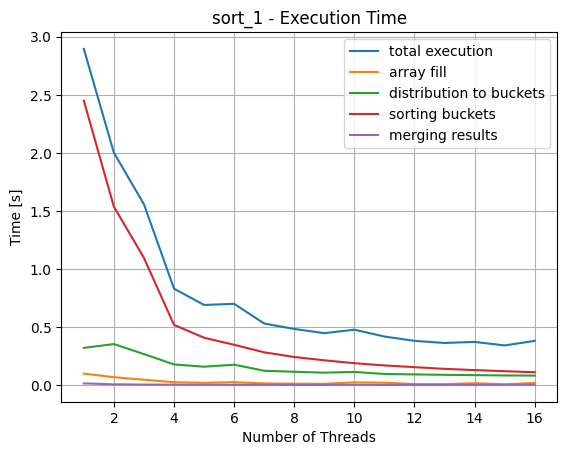

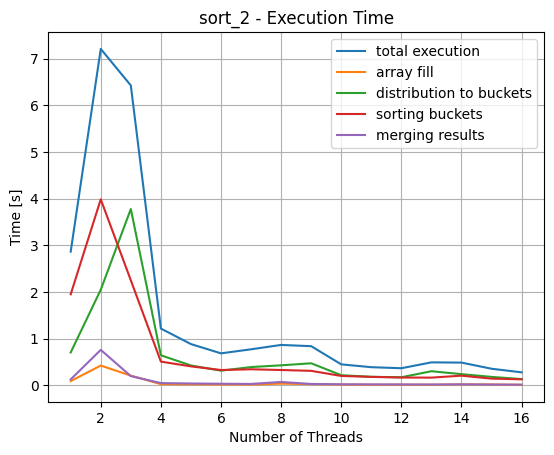

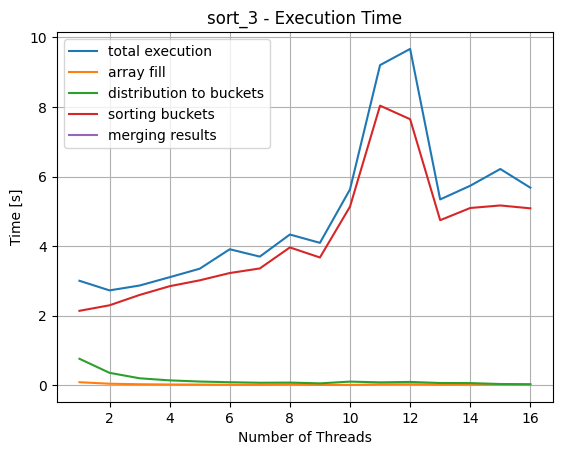

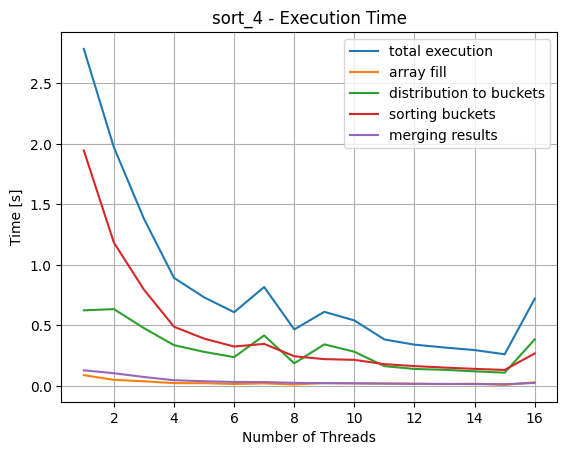

In [28]:
for series in udf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
    
    plt.plot(series_df["threads"], series_df["t_mean"], label="total execution")
    plt.plot(series_df["threads"], series_df["t1_mean"], label="array fill")
    plt.plot(series_df["threads"], series_df["t2_mean"], label="distribution to buckets")
    plt.plot(series_df["threads"], series_df["t3_mean"], label="sorting buckets")
    plt.plot(series_df["threads"], series_df["t4_mean"], label="merging results")
    
    plt.title(f"{series_nm} - Execution Time")
    plt.legend()
    plt.xlabel("Number of Threads")
    plt.ylabel("Time [s]")
    plt.grid()
    plt.show()

# Speedup

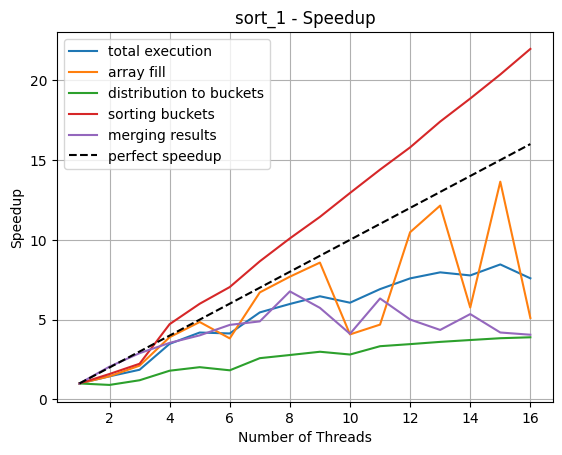

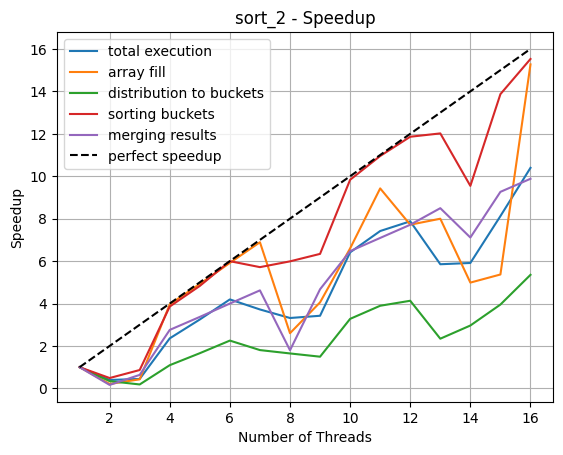

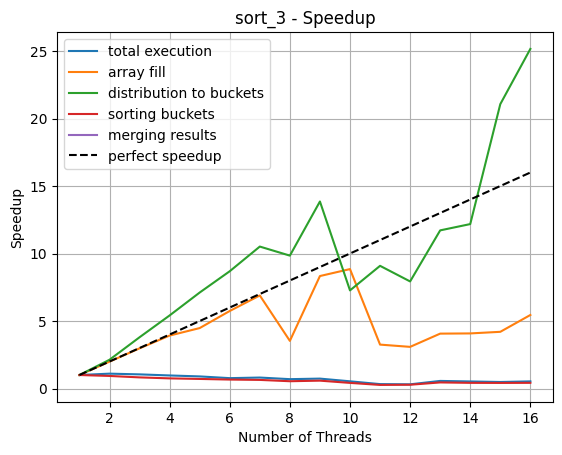

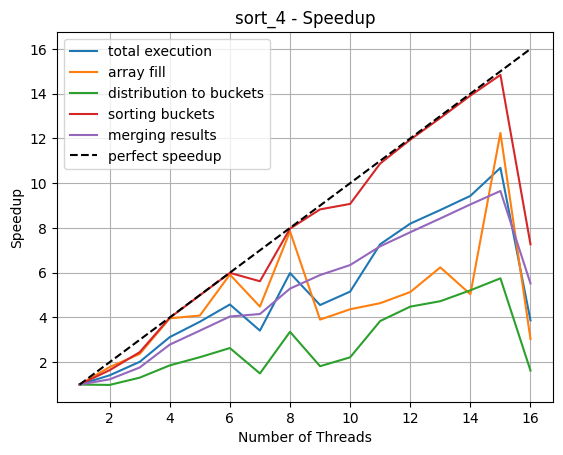

In [29]:
for series in udf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
    
    T1 = series_df[series_df["threads"] == 1]["t_mean"].values[0]
    T11 = series_df[series_df["threads"] == 1]["t1_mean"].values[0]
    T12 = series_df[series_df["threads"] == 1]["t2_mean"].values[0]
    T13 = series_df[series_df["threads"] == 1]["t3_mean"].values[0]
    T14 = series_df[series_df["threads"] == 1]["t4_mean"].values[0]
    
    plt.plot(series_df["threads"], T1/series_df["t_mean"], label="total execution")
    plt.plot(series_df["threads"], T11/series_df["t1_mean"], label="array fill")
    plt.plot(series_df["threads"], T12/series_df["t2_mean"], label="distribution to buckets")
    plt.plot(series_df["threads"], T13/series_df["t3_mean"], label="sorting buckets")
    plt.plot(series_df["threads"], T14/series_df["t4_mean"], label="merging results")
    
    perfect_speedup = series_df["threads"].values
    plt.plot(perfect_speedup, perfect_speedup, label="perfect speedup", linestyle='--', color='black')
    
    plt.title(f"{series_nm} - Speedup")
    plt.legend()
    plt.xlabel("Number of Threads")
    plt.grid()
    plt.ylabel("Speedup")
    plt.show()

# Buckets analysis

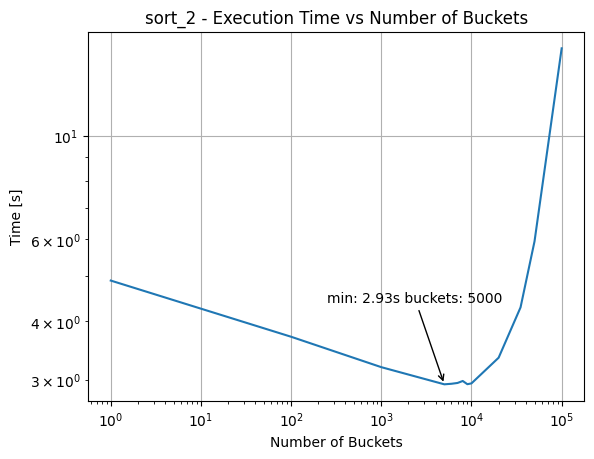

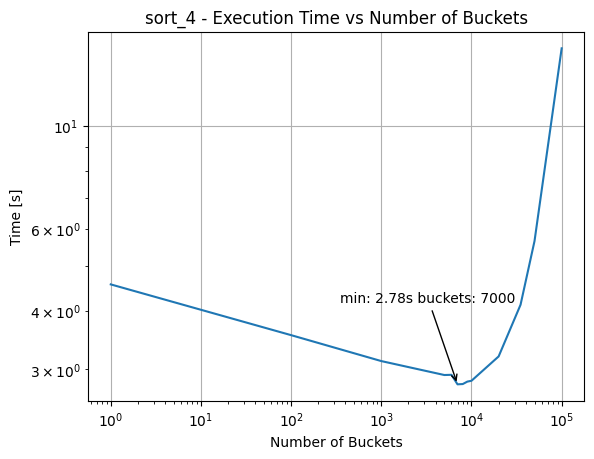

In [10]:
for series in bdf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
    
    plt.plot(series_df["buckets"], series_df["t_mean"], label="total execution")
    # plt.plot(series_df["buckets"], series_df["t1_mean"], label="array fill")
    # plt.plot(series_df["buckets"], series_df["t2_mean"], label="distribution to buckets")
    # plt.plot(series_df["buckets"], series_df["t3_mean"], label="sorting buckets")
    # plt.plot(series_df["buckets"], series_df["t4_mean"], label="merging results")
    
    plt.title(f"{series_nm} - Execution Time vs Number of Buckets")
    # plt.legend()
    plt.xlabel("Number of Buckets")
    plt.ylabel("Time [s]")
    plt.yscale("log")
    plt.xscale("log")
    plt.grid()

    min_index = series_df["t_mean"].idxmin()
    min_value = series_df["t_mean"].min()
    min_buckets = series_df["buckets"].iloc[min_index-13]
    plt.annotate(f"min: {min_value:.2f}s buckets: {min_buckets}", xy=(min_buckets, min_value), xytext=(min_buckets*0.05, min_value*1.5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.show()

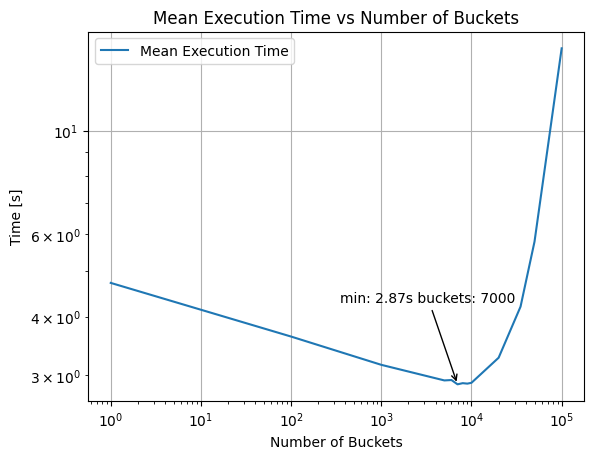

In [11]:
# Calculate the mean execution time for both algorithms
mean_bdf = bdf.groupby("buckets").agg(t_mean=("t_mean", "mean")).reset_index()

# Plot the mean execution time
plt.plot(mean_bdf["buckets"], mean_bdf["t_mean"], label="Mean Execution Time")

# Find the minimum value and its corresponding bucket
min_index = mean_bdf["t_mean"].idxmin()
min_value = mean_bdf["t_mean"].min()
min_buckets = mean_bdf["buckets"].iloc[min_index]

# Annotate the minimum value
plt.annotate(f"min: {min_value:.2f}s buckets: {min_buckets}", 
             xy=(min_buckets, min_value), 
             xytext=(min_buckets * 0.05, min_value * 1.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.title("Mean Execution Time vs Number of Buckets")
plt.xlabel("Number of Buckets")
plt.ylabel("Time [s]")
plt.yscale("log")
plt.xscale("log")
plt.grid()
plt.legend()
plt.show()

# Sort 2/4 oriented analysis

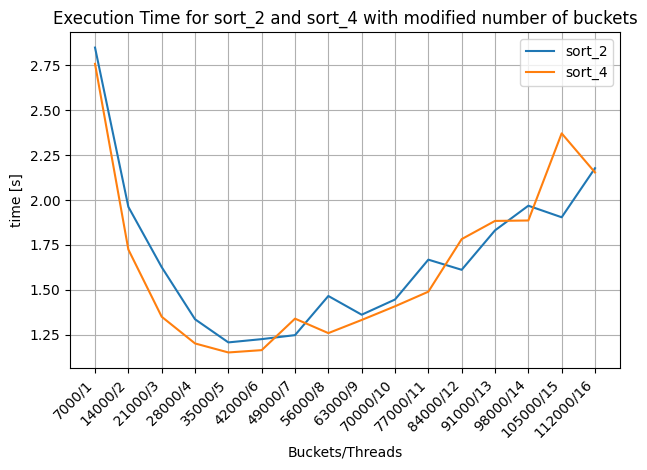

In [12]:
for series in odf.groupby("algo"):
    series_df = series[1]
    series_nm = series[0]
    
    # Create a combined x-axis label
    x_labels = [f"{buckets}/{threads}" for buckets, threads in zip(series_df["buckets"], series_df["threads"])]
    
    plt.plot(x_labels, series_df["t_mean"], label=f"{series_nm}")

plt.title("Execution Time for sort_2 and sort_4 with modified number of buckets")
plt.xlabel("Buckets/Threads")
plt.ylabel("time [s]")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

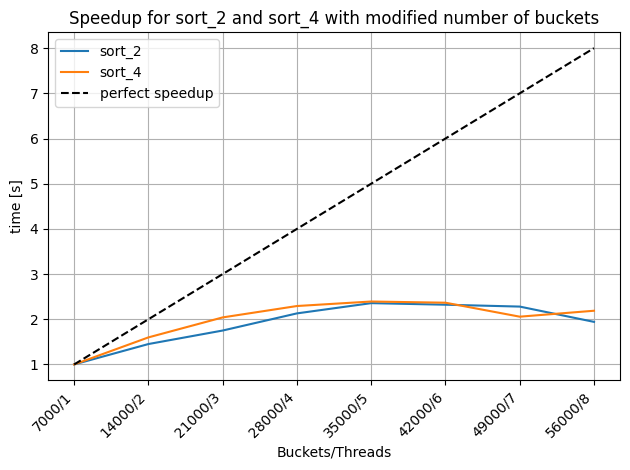

In [13]:
for series in odf.groupby("algo"):
    series_df = series[1][series[1]["threads"] <= 8]
    series_nm = series[0]
    
    # Create a combined x-axis label
    x_labels = [f"{buckets}/{threads}" for buckets, threads in zip(series_df["buckets"], series_df["threads"])]
    
    T1 = series_df[series_df["threads"] == 1]["t_mean"].values[0]
    
    plt.plot(x_labels, T1/series_df["t_mean"], label=f"{series_nm}")
    

X = np.arange(0, len(x_labels))
Y = np.arange(1, len(x_labels)+1)
plt.plot(X, Y, label="perfect speedup", linestyle='--', color='black')

plt.title("Speedup for sort_2 and sort_4 with modified number of buckets")
plt.xlabel("Buckets/Threads")
plt.ylabel("time [s]")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()